# THỰC HÀNH 03: PHÁT HIỆN ĐỐI TƯỢNG (OBJECT DETECTION) VỚI YOLO VÀ DETR.

## Thông tin chung

Bài thực hành thuộc môn **Thị Giác Máy Tính Nâng Cao** (*Advanced Computer Vision - K35 - HCMUS*).

- Thành viên nhóm:
  - Nguyễn Trọng Hiếu – 25C11042 (Nhóm trưởng)
  - Trương Lê Bảo Trân – 25C11071
- Giảng viên hướng dẫn: ThS. Nguyễn Mạnh Hùng

## Mục tiêu

- Tìm hiểu mô hình DETR.
- Huấn luyện mô hình trên tập dữ liệu Safety Helmet.
- Đánh giá hiệu năng mô hình.
- Thực hiện suy luận trên dữ liệu kiểm thử.

## Nguồn dữ liệu

Bộ dữ liệu được sử dụng trong bài thực hành là **Safety Helmet Dataset**, được công bố trên nền tảng Roboflow Universe. Bộ dữ liệu bao gồm các ảnh chứa người lao động trong môi trường xây dựng cùng với các nhãn đối tượng Helmet, Head và Person phục vụ cho bài toán phát hiện đối tượng (Object Detection).

Nguồn dữ liệu gốc được truy cập tại:

https://universe.roboflow.com/augmented-startups/safety-helmet-dataset-uvh1t



### 1. Kiểm tra môi trường

In [15]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Thiết bị sử dụng: {device}")

if device.type == "cuda":
    print("GPU đã được kích hoạt.")
else:
    print("Chưa phát hiện GPU.")

Thiết bị sử dụng: cuda
GPU đã được kích hoạt.


### 2. Kết nối Google Drive

In [16]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


### 3. Cài đặt mô hình DETR

In [17]:
# Cài đặt các thư viện cần thiết cho DETR,
# bao gồm Transformers, COCO API và các công cụ xử lý dữ liệu.

!pip install -q transformers datasets timm pycocotools

from transformers import (
    DetrImageProcessor,
    DetrForObjectDetection
)

# -----------------------------------------------------
# 1. Image Processor
# -----------------------------------------------------

processor = DetrImageProcessor.from_pretrained(
    "facebook/detr-resnet-50"
)

print("Đã tải DetrImageProcessor")

# -----------------------------------------------------
# 2. Label Mapping
# -----------------------------------------------------

id2label = {
    0: "head",
    1: "helmet",
    2: "person"
}

label2id = {
    "head": 0,
    "helmet": 1,
    "person": 2
}

# -----------------------------------------------------
# 3. DETR Model
# -----------------------------------------------------

model = DetrForObjectDetection.from_pretrained(
    "facebook/detr-resnet-50",
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

model.to(device)

print("Đã tải DETR ResNet-50")
print(model.class_labels_classifier.weight.shape)

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `91`.


Đã tải DetrImageProcessor


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |                                                                                        
---------------------------------------------------------------+------------+----------------------------------------------------------------------------------------
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |             

Đã tải DETR ResNet-50
torch.Size([4, 256])


### 4. Tải và chuẩn bị dữ liệu

In [18]:
# Tải bộ dữ liệu Safety Helmet (Dataset được lưu dưới định dạng COCO)
import os

DATASET_DIR = "/content/safety-helmet-dataset.v1i.coco"

if not os.path.exists(DATASET_DIR):
    print("Downloading dataset...")

    !pip install -q gdown

    GDRIVE_LINK = "https://drive.google.com/file/d/1qHouId0FNqHbdBTdrj2kEpQHQT1wpEae/view?usp=sharing"

    !gdown --fuzzy "$GDRIVE_LINK" -O dataset.zip

    !unzip -oq dataset.zip -d /content

    print("Dataset ready!")
else:
    print("Dataset already exists!")

Dataset already exists!


In [19]:
# Xây dựng Dataset cho DETR từ dữ liệu COCO.
# Các annotation được chuyển đổi sang định dạng đầu vào của DetrImageProcessor và loại bỏ lớp trung gian
# 'person-head-helmet' không tham gia huấn luyện.


from torchvision.datasets import CocoDetection
import torch
import os

class DetrCocoDataset(CocoDetection):

    def __init__(self, img_folder, processor):

        super().__init__(
            img_folder,
            os.path.join(
                img_folder,
                "_annotations.coco.json"
            )
        )

        self.processor = processor

        # Remap COCO labels
        self.label_map = {
            1: 0,   # head
            2: 1,   # helmet
            3: 2    # person
        }

    def __getitem__(self, idx):

        image, annotations = super().__getitem__(idx)

        filtered_annotations = []

        for ann in annotations:

            # Bỏ class ảo
            if ann["category_id"] == 0:
                continue

            ann = ann.copy()

            # Remap về 0,1,2
            ann["category_id"] = self.label_map[
                ann["category_id"]
            ]

            filtered_annotations.append(
                ann
            )

        encoding = self.processor(
            images=image,
            annotations={
                "image_id": self.ids[idx],
                "annotations": filtered_annotations
            },
            return_tensors="pt"
        )

        return {
            "pixel_values":
                encoding["pixel_values"].squeeze(0),

            "labels":
                encoding["labels"][0]
        }


# =====================
# DATASET
# =====================

train_dataset = DetrCocoDataset(
    os.path.join(DATASET_DIR, "train"),
    processor
)

val_dataset = DetrCocoDataset(
    os.path.join(DATASET_DIR, "valid"),
    processor
)

test_dataset = DetrCocoDataset(
    os.path.join(DATASET_DIR, "test"),
    processor
)

# =====================
# COLLATE FUNCTION
# =====================

def collate_fn(batch):

    pixel_values = torch.stack(
        [x["pixel_values"] for x in batch]
    )

    return {
        "pixel_values": pixel_values,

        "pixel_mask": torch.ones(
            (
                pixel_values.shape[0],
                pixel_values.shape[2],
                pixel_values.shape[3]
            ),
            dtype=torch.long
        ),

        "labels": [
            x["labels"]
            for x in batch
        ]
    }

print("\n========== DATASET SUMMARY ==========")

print(f"Train images : {len(train_dataset)}")
print(f"Valid images : {len(val_dataset)}")
print(f"Test images  : {len(test_dataset)}")

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!

========== DATASET SUMMARY ==========
Train images : 761
Valid images : 218
Test images  : 109


### 5. Huấn luyện mô hình

In [28]:
# Cấu hình quá trình huấn luyện DETR.
# Sử dụng Early Stopping để tránh overfitting và
# tự động nạp lại checkpoint có Validation Loss tốt nhất.

from transformers import (
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

# =====================
# TRAINING CONFIG
# =====================

training_args = TrainingArguments(
    output_dir="./helmet_detr",

    num_train_epochs=100,

    # Learning rate
    learning_rate=1e-4,
    weight_decay=1e-4,
    warmup_ratio=0.1,

    # Batch size
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,

    # Effective Batch = 16
    gradient_accumulation_steps=8,

    # Validation mỗi epoch
    eval_strategy="epoch",
    save_strategy="epoch",

    # Load checkpoint tốt nhất
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    remove_unused_columns=False,
    fp16=True,

    # Logging
    logging_strategy="epoch",

    save_total_limit=3
)

# =====================
# TRAINER
# =====================

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    data_collator=collate_fn,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=20
        )
    ]
)

# =====================
# TRAIN MODEL
# =====================

trainer.train()

print("\n========== TRAINING FINISHED ==========")
print("Best checkpoint:")
print(trainer.state.best_model_checkpoint)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss
1,3.619699,3.463648
2,2.601974,1.993506
3,1.804482,1.666939
4,1.613489,1.522646
5,1.571926,1.421707
6,1.464215,1.394484
7,1.347969,1.277480
8,1.278231,1.401805
9,1.273978,1.346834
10,1.403609,1.252890


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['model.backbone.model.conv1.weight', 'model.backbone.model.bn1.weight', 'model.backbone.model.bn1.bias', 'model.backbone.model.bn1.running_mean', 'model.backbone.model.bn1.running_var', 'model.backbone.model.layer1.0.conv1.weight', 'model.backbone.model.layer1.0.bn1.weight', 'model.backbone.model.layer1.0.bn1.bias', 'model.backbone.model.layer1.0.bn1.running_mean', 'model.backbone.model.layer1.0.bn1.running_var', 'model.backbone.model.layer1.0.conv2.weight', 'model.backbone.model.layer1.0.bn2.weight', 'model.backbone.model.layer1.0.bn2.bias', 'model.backbone.model.layer1.0.bn2.running_mean', 'model.backbone.model.layer1.0.bn2.running_var', 'model.backbone.model.layer1.0.conv3.weight', 'model.backbone.model.layer1.0.bn3.weight', 'model.backbone.model.layer1.0.bn3.bias', 'model.backbone.model.layer1.0.bn3.running_mean', 'model.backbone.model.layer1.0.bn3.running_var', 'model.backbone.model.layer1.0.downsample.0.weigh


========== TRAINING FINISHED ==========
Best checkpoint:
./helmet_detr/checkpoint-2256


### 6. Đánh giá kết quả huấn luyện

**6.1 Đánh giá mô hình trên tập Validation**

In [30]:
# Đánh giá mô hình trên tập Validation theo chuẩn COCO.
# Các dự đoán của DETR được chuyển đổi sang bounding box thực tế
# trước khi tính Recall, mAP50 và mAP50-95.

!pip install -q torchmetrics

from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torch.utils.data import DataLoader
import torch

# =====================
# VALIDATION DATALOADER
# =====================

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn
)

# =====================
# mAP METRIC
# =====================

metric = MeanAveragePrecision()

model.eval()

# =====================
# VALIDATION LOOP
# =====================

with torch.no_grad():

    for batch in val_loader:

        pixel_values = batch["pixel_values"].to(device)
        pixel_mask = batch["pixel_mask"].to(device)

        outputs = model(
            pixel_values=pixel_values,
            pixel_mask=pixel_mask
        )

        # Chuyển output DETR sang bbox thực tế
        target_sizes = torch.stack(
            [t["orig_size"] for t in batch["labels"]]
        ).to(device)

        predictions = processor.post_process_object_detection(
            outputs,
            threshold=0.25,
            target_sizes=target_sizes
        )

        # Chuẩn bị Ground Truth
        targets = []

        for target in batch["labels"]:

            h, w = target["orig_size"]

            boxes = target["boxes"].clone()

            gt_boxes = torch.zeros_like(boxes)

            # cxcywh -> xyxy
            gt_boxes[:,0] = (boxes[:,0] - boxes[:,2]/2) * w
            gt_boxes[:,1] = (boxes[:,1] - boxes[:,3]/2) * h
            gt_boxes[:,2] = (boxes[:,0] + boxes[:,2]/2) * w
            gt_boxes[:,3] = (boxes[:,1] + boxes[:,3]/2) * h

            targets.append({
                "boxes": gt_boxes.cpu(),
                "labels": target["class_labels"].cpu()
            })

        # Chuẩn bị Prediction
        preds = []

        for pred in predictions:

            preds.append({
                "boxes": pred["boxes"].cpu(),
                "scores": pred["scores"].cpu(),
                "labels": pred["labels"].cpu()
            })

        metric.update(
            preds,
            targets
        )

# =====================
# COMPUTE METRICS
# =====================

results = metric.compute()

# =====================
# DISPLAY RESULTS
# =====================

print("========== DETR ==========")
print(f"Recall    : {results['mar_100']:.4f}")
print(f"mAP50     : {results['map_50']:.4f}")
print(f"mAP50-95  : {results['map']:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 22.6 MB/s eta 0:00:00
========== DETR ==========
Recall    : 0.3550
mAP50     : 0.5613
mAP50-95  : 0.2780


**Nhận xét:** Kết quả đánh giá trên tập Validation cho thấy mô hình DETR đạt Recall = 0.3550, mAP50 = 0.5613 và mAP50-95 = 0.2780. Mặc dù mô hình có khả năng phát hiện đúng một số đối tượng trong ảnh, hiệu năng tổng thể vẫn còn hạn chế, đặc biệt ở các ngưỡng IoU cao. Điều này cho thấy DETR chưa khai thác hiệu quả đặc trưng của bộ dữ liệu Safety Helmet và gặp khó khăn trong việc phát hiện các đối tượng có kích thước nhỏ.

**6.2 Learning Curve**

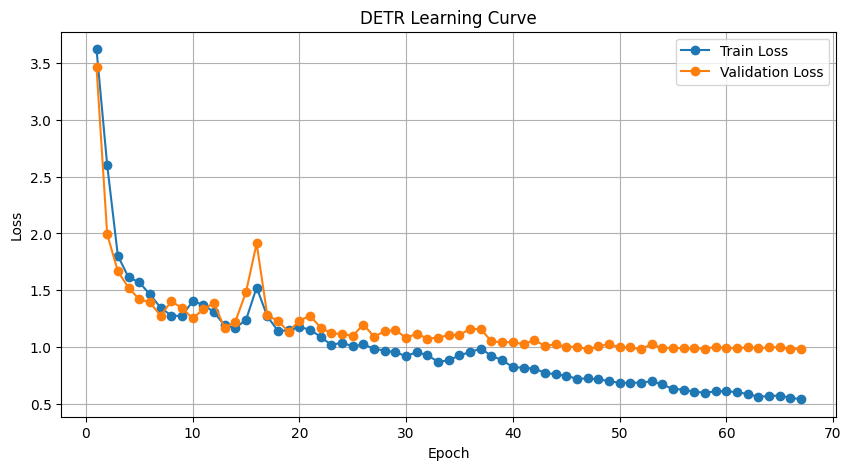

In [31]:
# Trực quan hóa Learning Curve nhằm theo dõi
# sự thay đổi của Train Loss và Validation Loss
# trong suốt quá trình huấn luyện.

# =====================
# LOAD TRAINING LOGS
# =====================

import pandas as pd

logs = pd.DataFrame(
    trainer.state.log_history
)

logs.head()

# =====================
# EXTRACT TRAIN / VAL LOSS
# =====================

train_logs = logs.dropna(
    subset=["loss"]
)

eval_logs = logs.dropna(
    subset=["eval_loss"]
)

# =====================
# PLOT LEARNING CURVE
# =====================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    train_logs["epoch"],
    train_logs["loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    eval_logs["epoch"],
    eval_logs["eval_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "DETR Learning Curve"
)

plt.grid(True)
plt.legend()

plt.show()

**Nhận xét:** Đồ thị Learning Curve cho thấy cả Train Loss và Validation Loss đều giảm mạnh trong giai đoạn đầu huấn luyện, chứng tỏ mô hình đã học được các đặc trưng cơ bản của bộ dữ liệu. Sau khoảng 20 epoch, tốc độ giảm của Loss chậm lại và mô hình dần hội tụ. Từ khoảng epoch 40 trở đi, Validation Loss gần như không còn cải thiện trong khi Train Loss tiếp tục giảm, cho thấy mô hình bắt đầu xuất hiện hiện tượng overfitting nhẹ. Tuy nhiên, khoảng cách giữa hai đường Loss không quá lớn, cho thấy quá trình huấn luyện vẫn tương đối ổn định. Early Stopping đã dừng quá trình huấn luyện tại epoch 67 nhằm tránh việc tiếp tục học quá mức trên tập huấn luyện.

**6.3. Đánh giá hiệu năng theo từng lớp đối tượng**

In [46]:
# Phân tích hiệu năng của DETR trên từng lớp đối tượng.
# Chỉ số AP50-95 theo lớp giúp xác định lớp nào
# đang gây ảnh hưởng lớn đến mAP tổng thể.

!pip install -q torchmetrics

from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torch.utils.data import DataLoader
import pandas as pd
import torch

# =====================
# DATALOADER
# =====================

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn
)

# =====================
# METRIC
# =====================

metric = MeanAveragePrecision(
    class_metrics=True
)

model.eval()

# =====================
# LOOP
# =====================

with torch.no_grad():

    for batch in val_loader:

        pixel_values = batch["pixel_values"].to(device)
        pixel_mask = batch["pixel_mask"].to(device)

        outputs = model(
            pixel_values=pixel_values,
            pixel_mask=pixel_mask
        )

        target_sizes = torch.stack(
            [
                t["orig_size"]
                for t in batch["labels"]
            ]
        ).to(device)

        predictions = processor.post_process_object_detection(
            outputs,
            threshold=0.25,
            target_sizes=target_sizes
        )

        preds = []

        for pred in predictions:

            preds.append({
                "boxes": pred["boxes"].cpu(),
                "scores": pred["scores"].cpu(),
                "labels": pred["labels"].cpu()
            })

        targets = []

        for target in batch["labels"]:

            h, w = target["orig_size"]

            boxes = target["boxes"].clone()

            gt_boxes = torch.zeros_like(boxes)

            # cxcywh -> xyxy

            gt_boxes[:,0] = (
                boxes[:,0] - boxes[:,2]/2
            ) * w

            gt_boxes[:,1] = (
                boxes[:,1] - boxes[:,3]/2
            ) * h

            gt_boxes[:,2] = (
                boxes[:,0] + boxes[:,2]/2
            ) * w

            gt_boxes[:,3] = (
                boxes[:,1] + boxes[:,3]/2
            ) * h

            targets.append({
                "boxes": gt_boxes.cpu(),
                "labels": target[
                    "class_labels"
                ].cpu()
            })

        metric.update(
            preds,
            targets
        )

# =====================
# RESULTS
# =====================

results = metric.compute()

print(results.keys())

# =====================
# PER CLASS AP
# =====================

class_names = [
    "head",
    "helmet",
    "person"
]

ap_per_class = (
    results["map_per_class"]
    .cpu()
    .numpy()
)

classes = (
    results["classes"]
    .cpu()
    .numpy()
)

rows = []

for cls_id, ap in zip(
    classes,
    ap_per_class
):

    rows.append([
        class_names[int(cls_id)],
        float(ap)
    ])

df = pd.DataFrame(
    rows,
    columns=[
        "Class",
        "AP50-95"
    ]
)

print("\n========== PER CLASS AP ==========\n")
print(df)

print("\nOverall mAP50-95:",
      float(results["map"]))

dict_keys(['map', 'map_50', 'map_75', 'map_small', 'map_medium', 'map_large', 'mar_1', 'mar_10', 'mar_100', 'mar_small', 'mar_medium', 'mar_large', 'map_per_class', 'mar_100_per_class', 'classes'])

========== PER CLASS AP ==========

    Class   AP50-95
0    head  0.000000
1  helmet  0.402485
2  person  0.431594

Overall mAP50-95: 0.2780265212059021


**Nhận xét:** Kết quả đánh giá theo từng lớp cho thấy mô hình DETR đạt AP50-95 lần lượt là 0.402 đối với lớp Helmet và 0.432 đối với lớp Person. Tuy nhiên, mô hình không phát hiện hiệu quả lớp Head (AP50-95 = 0.000). Điều này làm giảm đáng kể giá trị mAP50-95 trung bình xuống còn 0.278. Kết quả cho thấy DETR hoạt động tương đối tốt đối với các đối tượng có kích thước trung bình và lớn, nhưng gặp khó khăn trong việc phát hiện các đối tượng nhỏ trên bộ dữ liệu Safety Helmet.

### 7.Đánh giá mô hình tốt nhất trên tập Test

In [33]:
# Đánh giá mô hình tốt nhất trên tập Test độc lập.
# Các chỉ số được sử dụng gồm Recall, mAP50 và mAP50-95.

!pip install -q torchmetrics

from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torch.utils.data import DataLoader
import torch

# =====================
# LOAD BEST MODEL
# =====================

model = trainer.model

model.to(device)
model.eval()

# =====================
# TEST DATALOADER
# =====================

test_loader = DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn
)

# =====================
# mAP METRIC
# =====================

metric = MeanAveragePrecision()

# =====================
# TEST LOOP
# =====================

with torch.no_grad():

    for batch in test_loader:

        pixel_values = batch[
            "pixel_values"
        ].to(device)

        pixel_mask = batch[
            "pixel_mask"
        ].to(device)

        outputs = model(
            pixel_values=pixel_values,
            pixel_mask=pixel_mask
        )


        target_sizes = torch.stack(
            [
                t["orig_size"]
                for t in batch["labels"]
            ]
        ).to(device)

        predictions = (
            processor
            .post_process_object_detection(
                outputs,
                threshold=0.25,
                target_sizes=target_sizes
            )
        )

        # ------------------
        # Ground Truth
        # ------------------

        targets = []

        for target in batch["labels"]:

            h, w = target["orig_size"]

            boxes = (
                target["boxes"]
                .clone()
            )

            gt_boxes = torch.zeros_like(
                boxes
            )

            # cxcywh -> xyxy

            gt_boxes[:,0] = (
                boxes[:,0]
                - boxes[:,2]/2
            ) * w

            gt_boxes[:,1] = (
                boxes[:,1]
                - boxes[:,3]/2
            ) * h

            gt_boxes[:,2] = (
                boxes[:,0]
                + boxes[:,2]/2
            ) * w

            gt_boxes[:,3] = (
                boxes[:,1]
                + boxes[:,3]/2
            ) * h

            targets.append({

                "boxes":
                    gt_boxes.cpu(),

                "labels":
                    target[
                        "class_labels"
                    ].cpu()
            })

        # ------------------
        # Predictions
        # ------------------

        preds = []

        for pred in predictions:

            preds.append({

                "boxes":
                    pred["boxes"]
                    .cpu(),

                "scores":
                    pred["scores"]
                    .cpu(),

                "labels":
                    pred["labels"]
                    .cpu()
            })

        metric.update(
            preds,
            targets
        )

# =====================
# COMPUTE METRICS
# =====================

results = metric.compute()

mar100 = results[
    "mar_100"
].item()

map50 = results[
    "map_50"
].item()

map5095 = results[
    "map"
].item()

# =====================
# DISPLAY RESULTS
# =====================

print(
    "\n========== DETR TEST =========="
)

print(
    f"mAR@100   : {mar100:.4f}"
)

print(
    f"mAP50     : {map50:.4f}"
)

print(
    f"mAP50-95  : {map5095:.4f}"
)


========== DETR TEST ==========
mAR@100   : 0.3567
mAP50     : 0.5317
mAP50-95  : 0.2681


**Nhận xét:** Trên tập Test, mô hình DETR đạt mAR@100 = 0.3567, mAP50 = 0.5317 và mAP50-95 = 0.2681. Kết quả này tương đối gần với các chỉ số thu được trên tập Validation (mAP50 = 0.5613, mAP50-95 = 0.2780), cho thấy mô hình có khả năng tổng quát hóa tương đối ổn định và không xuất hiện hiện tượng suy giảm hiệu năng đáng kể trên dữ liệu chưa được quan sát trong quá trình huấn luyện. Tuy nhiên, giá trị mAP50-95 vẫn còn ở mức thấp, cho thấy DETR gặp khó khăn trong việc định vị chính xác các đối tượng, đặc biệt là các đối tượng có kích thước nhỏ trong bộ dữ liệu Safety Helmet.

### 8. Dự đoán trên ảnh thử nghiệm

Image: helmet-57-_jpg.rf.011042b64595377970edee043e9303b2.jpg
Detected objects: 13


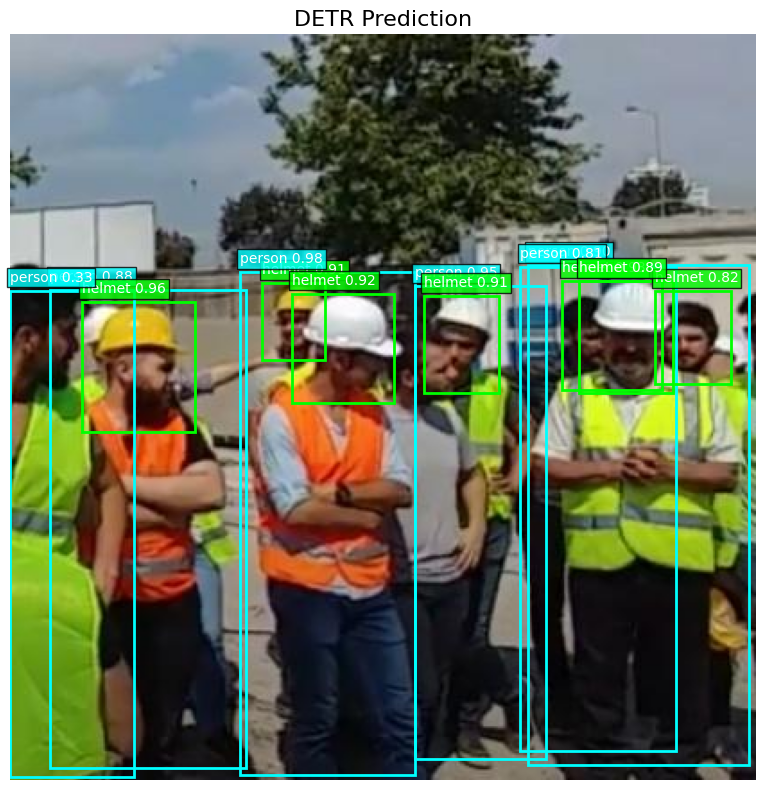

In [47]:
# Thực hiện suy luận trên ảnh thử nghiệm bằng mô hình DETR
# và hiển thị kết quả phát hiện đối tượng trực quan.

import random
import os
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from PIL import Image

# ---------------------
# Random Image
# ---------------------

idx = random.randint(
    0,
    len(test_dataset) - 1
)

img_info = test_dataset.coco.loadImgs(
    test_dataset.ids[idx]
)[0]

image_path = os.path.join(
    test_dataset.root,
    img_info["file_name"]
)

image = Image.open(
    image_path
).convert("RGB")

print(f"Image: {img_info['file_name']}")

# ---------------------
# Prediction
# ---------------------

inputs = processor(
    images=image,
    return_tensors="pt"
)

pixel_values = inputs[
    "pixel_values"
].to(device)

pixel_mask = inputs.get(
    "pixel_mask"
)

if pixel_mask is not None:
    pixel_mask = pixel_mask.to(device)

model.eval()

with torch.no_grad():

    outputs = model(
        pixel_values=pixel_values,
        pixel_mask=pixel_mask
    )

target_sizes = torch.tensor(
    [[image.height, image.width]]
).to(device)

results = (
    processor
    .post_process_object_detection(
        outputs,
        threshold=0.25,
        target_sizes=target_sizes
    )[0]
)

print(
    f"Detected objects: {len(results['scores'])}"
)

# ---------------------
# Colors by Class
# ---------------------

colors = {
    0: "red",       # head
    1: "lime",      # helmet
    2: "cyan"       # person
}

# ---------------------
# Visualization
# ---------------------

fig, ax = plt.subplots(
    1,
    figsize=(12, 8)
)

ax.imshow(image)

for score, label, box in zip(
    results["scores"],
    results["labels"],
    results["boxes"]
):

    label = int(label)

    x1, y1, x2, y2 = (
        box.cpu().numpy()
    )

    color = colors.get(
        label,
        "yellow"
    )

    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor=color,
        facecolor="none"
    )

    ax.add_patch(rect)

    class_name = id2label.get(
        label,
        "UNK"
    )

    ax.text(
        x1,
        y1 - 5,
        f"{class_name} {score:.2f}",
        fontsize=10,
        color="white",
        bbox=dict(
            facecolor=color,
            alpha=0.8,
            pad=2
        )
    )

plt.title(
    "DETR Prediction",
    fontsize=16
)

plt.axis("off")
plt.tight_layout()
plt.show()

**Nhận xét:** Kết quả dự đoán cho thấy mô hình DETR nhận diện tương đối tốt hai lớp **Person** và **Helmet**, với hầu hết các đối tượng đều được phát hiện và gán nhãn đúng cùng độ tin cậy cao (trên 0.8). Các bounding box của lớp Person bao phủ tương đối chính xác toàn bộ cơ thể người lao động, trong khi lớp Helmet cũng được phát hiện ổn định trên nhiều đối tượng khác nhau. Tuy nhiên, mô hình không dự đoán được lớp **Head**, phù hợp với kết quả đánh giá trước đó khi AP50-95 của lớp Head bằng 0.000. Điều này cho thấy DETR gặp khó khăn trong việc phát hiện các đối tượng có kích thước nhỏ trên bộ dữ liệu Safety Helmet.

### 9. Lưu mô hình tốt nhất vào Google Drive

In [36]:
# Lưu Best DETR Model vào Google Drive

import shutil

BEST_MODEL = trainer.state.best_model_checkpoint

print("Best checkpoint:")
print(BEST_MODEL)

SAVE_DIR = "/content/drive/MyDrive/helmet_detr_best"

shutil.copytree(
    BEST_MODEL,
    SAVE_DIR,
    dirs_exist_ok=True
)

print("\nĐã lưu Best Model vào:")
print(SAVE_DIR)

Best checkpoint:
./helmet_detr/checkpoint-2256

Đã lưu Best Model vào:
/content/drive/MyDrive/helmet_detr_best


In [37]:
import shutil

shutil.make_archive(
    "/content/helmet_detr_best",
    "zip",
    "/content/drive/MyDrive/helmet_detr_best"
)

print("Done")

Done


### 10. Nhận xét

**Kết quả đạt được:**

Huấn luyện thành công mô hình DETR trên bộ dữ liệu Safety Helmet Detection.

Mô hình nhận diện được ba lớp đối tượng gồm Head, Helmet và Person.

Mô hình đạt kết quả trên tập Test với:

mAR@100: 0,357

mAP@0.5: 0,532

mAP@0.5:0.95: 0,268

Mô hình nhận diện tương đối tốt các lớp Helmet và Person, tuy nhiên gặp khó khăn với lớp Head.

Quá trình huấn luyện hội tụ ổn định và không xuất hiện hiện tượng overfitting nghiêm trọng.

**Ưu điểm:**

Kiến trúc End-to-End đơn giản.

Nhận diện tốt các lớp Helmet và Person.

Khả năng tổng quát hóa tương đối ổn định trên tập Test.

**Nhược điểm:**

Hiệu năng thấp đối với lớp Head.

Khả năng phát hiện vật thể nhỏ còn hạn chế.

mAP50-95 chưa cao so với yêu cầu thực tế.